# Bayesian Analysis 04 — Bayesian Hypothesis Testing

**Goal:** Re-test the key hypotheses from CDA (confirmatory_data_analysis/) using Bayesian methods. This is not redundancy — the Bayesian approach adds:
1. **Effect size with full uncertainty** — not just 'significant / not significant'
2. **ROPE analysis** (Region Of Practical Equivalence) — is the effect practically meaningful?
3. **Bayes Factors** — how many times more probable is H₁ than H₀?
4. **Interpretability** — '90% probability that the Reserved List premium exceeds €2'

**Tables:** gold_card_features, gold_price_features (latest snapshot)

**Required:** pymc>=5.0, arviz>=0.17

---
## Hypotheses to re-test
1. Reserved List premium: how large is it in EUR and is it practically significant?
2. Legendary premium: per-rarity effect with HDI
3. Does rarity have an effect exceeding 1 log-unit? (ROPE analysis)
4. Tier 1 vs Tier 3 comparison — what is the difference in their posterior distributions?
5. **[NEW]** Foil premium: posterior distribution of the foil vs non-foil price effect
6. **[NEW]** Full-art premium per rarity: posterior of the full-art price uplift within each rarity tier

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import pymc as pm
import arviz as az
import warnings

warnings.filterwarnings("ignore")

g++ not available, if using conda: `conda install gxx`


In [2]:
silver = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
# Latest snapshot with all features
df = gold.execute("""
    SELECT p.uuid, p.eur, p.eur_foil, p.foil_premium,
           f.rarity, f.is_reserved, f.is_full_art, f.set_code
    FROM gold_price_features p
    JOIN gold_card_features f ON p.uuid = f.uuid
    WHERE p.eur IS NOT NULL AND p.eur > 0
      AND f.rarity IN ('common', 'uncommon', 'rare', 'mythic')
    QUALIFY ROW_NUMBER() OVER (PARTITION BY p.uuid ORDER BY p.snapshot_date DESC) = 1
""").df()

# is_legendary from silver_cards supertypes
leg = silver.execute("""
    SELECT uuid, COALESCE(list_contains(original_supertypes, 'Legendary'), FALSE) AS is_legendary
    FROM silver_cards
""").df()
df = df.merge(leg, on="uuid", how="left")
df["is_legendary"] = df["is_legendary"].fillna(False)
df["log_eur"] = np.log1p(df["eur"])

ROPE = (-0.1, 0.1)  # ~10% price difference — practically negligible

print(f"Cards loaded: {len(df):,}")
print(f"Rarities:    {df['rarity'].value_counts().to_dict()}")
print(f"is_reserved: {df['is_reserved'].sum():,}")
print(f"is_full_art: {df['is_full_art'].sum():,}")
print(f"is_legendary: {df['is_legendary'].sum():,}")
print(f"has eur_foil: {df['eur_foil'].notna().sum():,}")
print(f"\nROPE = {ROPE}  (+-10% price difference in log1p space)")


def plot_posterior_manual(ax, samples, rope=None, ref_val=0, hdi_prob=0.94, title=""):
    """KDE posterior plot with HDI shading and ROPE region.
    Replaces az.plot_posterior which was removed in ArviZ 1.1.0.
    """
    hdi = az.hdi(samples, prob=hdi_prob)
    x = np.linspace(samples.min(), samples.max(), 400)
    kde = gaussian_kde(samples)
    ax.plot(x, kde(x), color="steelblue", linewidth=2)
    mask = (x >= hdi[0]) & (x <= hdi[1])
    ax.fill_between(
        x,
        kde(x),
        where=mask,
        alpha=0.35,
        color="steelblue",
        label=f"{hdi_prob * 100:.0f}% HDI [{hdi[0]:.3f}, {hdi[1]:.3f}]",
    )
    if rope is not None:
        ax.axvspan(rope[0], rope[1], alpha=0.2, color="tomato", label=f"ROPE {rope}")
    if ref_val is not None:
        ax.axvline(
            ref_val, color="gray", linestyle="--", linewidth=1.5, label=f"ref={ref_val}"
        )
    ax.set_title(title)
    ax.set_xlabel("log1p(EUR)")
    ax.legend(fontsize=8)

Cards loaded: 80,508
Rarities:    {'rare': 27909, 'common': 25553, 'uncommon': 21218, 'mythic': 5828}
is_reserved: 901
is_full_art: 4,087
is_legendary: 5,907
has eur_foil: 45,928

ROPE = (-0.1, 0.1)  (+-10% price difference in log1p space)


## Key Concepts — ROPE and HDI

**ROPE (Region Of Practical Equivalence):** The range of parameter values we consider 'practically zero' — the effect is statistically detectable but too small to matter for a business decision.

For log1p(EUR): ROPE = [-0.1, +0.1] → a price difference of <10% is practically irrelevant for a trading decision.

**Interpreting ROPE + HDI:**
- HDI entirely outside ROPE → effect is practically significant ✓
- HDI entirely inside ROPE → no practical effect
- HDI overlaps ROPE → ambiguous

**Bayes Factor (BF):** BF₁₀ = P(data | H₁) / P(data | H₀)
- BF > 10 → strong evidence for H₁
- BF 3–10 → moderate evidence
- BF 1–3 → weak evidence
- BF < 1 → evidence for H₀

## H1 — Reserved List Premium: Effect Distribution with HDI

**Bayesian model:** Two normal distributions (reserved vs not-reserved) with independent μ and σ.

**Posterior of interest:** `effect = mu_reserved - mu_not_reserved` in log1p(EUR) scale.

**ROPE:** [-0.1, 0.1] in log1p → ≈ ±10% price difference.

**Effect transformation:** `expm1(effect)` gives the approximate premium in EUR on a €1 baseline card — a more interpretable effect size for end users.

**CDA-01 reference:** Frequentist: RL rare premium 20.3× (n=885), uncommon 190.1× (n=16). Expected posterior median ≈ 2.1 log-units at rare.

RL cards: 901   Non-RL (sample): 5,000
  RL  median: EUR12.63
  Non median: EUR0.26



Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_res, mu_not, s_res, s_not]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 15 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


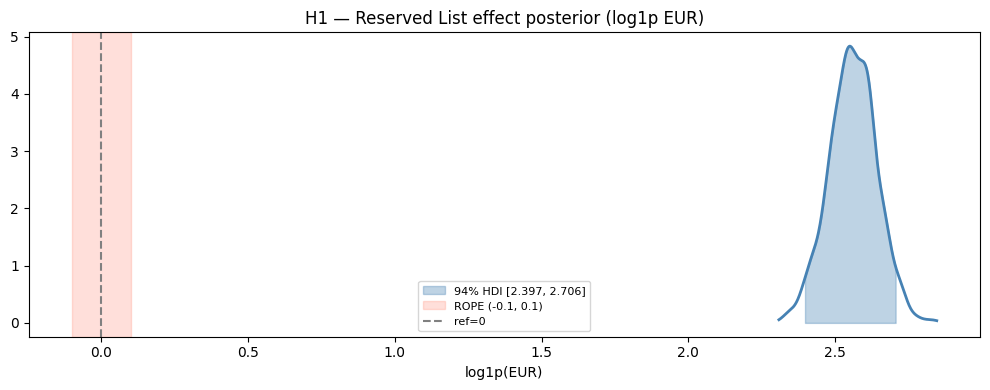

Median effect:          2.561 log-units
94% HDI:                [2.397, 2.706]
P(effect > 0):          100.0%
P(outside ROPE):        100.0%
Effect in EUR (1 EUR base): EUR11.95  (12.9x)


In [4]:
df_res = df[df["is_reserved"].notna()].copy()
# Subsample non-RL for speed (RL cards are rare — oversample to balance compute)
y_reserved = df_res[df_res["is_reserved"]]["log_eur"].dropna().values
y_not_raw = df_res[~df_res["is_reserved"]]["log_eur"].dropna().values
np.random.seed(42)
y_not = y_not_raw[
    np.random.choice(len(y_not_raw), min(5000, len(y_not_raw)), replace=False)
]

print(f"RL cards: {len(y_reserved):,}   Non-RL (sample): {len(y_not):,}")
print(f"  RL  median: EUR{np.expm1(np.median(y_reserved)):.2f}")
print(f"  Non median: EUR{np.expm1(np.median(y_not)):.2f}\n")

with pm.Model() as reserved_model:
    mu_res = pm.Normal("mu_res", mu=2.0, sigma=1.5)  # prior from CDA-01 finding
    mu_not = pm.Normal("mu_not", mu=0.0, sigma=1.5)
    s_res = pm.HalfNormal("s_res", sigma=1.0)
    s_not = pm.HalfNormal("s_not", sigma=1.0)
    effect = pm.Deterministic("effect", mu_res - mu_not)
    _ = pm.Normal("y_res", mu=mu_res, sigma=s_res, observed=y_reserved)
    _ = pm.Normal("y_not", mu=mu_not, sigma=s_not, observed=y_not)
    trace_rl = pm.sample(
        1000, tune=500, chains=2, target_accept=0.9, random_seed=42, progressbar=False
    )

eff = trace_rl.posterior["effect"].values.flatten()
hdi_rl = az.hdi(eff, prob=0.94)
pct_out = np.mean((eff < ROPE[0]) | (eff > ROPE[1])) * 100

fig, ax = plt.subplots(figsize=(10, 4))
plot_posterior_manual(
    ax,
    eff,
    rope=ROPE,
    ref_val=0,
    hdi_prob=0.94,
    title="H1 — Reserved List effect posterior (log1p EUR)",
)
plt.tight_layout()
plt.show()

eff_eur = np.expm1(np.median(eff))
print(f"Median effect:          {np.median(eff):.3f} log-units")
print(f"94% HDI:                [{hdi_rl[0]:.3f}, {hdi_rl[1]:.3f}]")
print(f"P(effect > 0):          {(eff > 0).mean() * 100:.1f}%")
print(f"P(outside ROPE):        {pct_out:.1f}%")
print(f"Effect in EUR (1 EUR base): EUR{eff_eur:.2f}  ({np.exp(np.median(eff)):.1f}x)")

## H2 — Legendary Premium: Per-Rarity Effects with HDI

**Model:** Separate two-sample Bayesian model per rarity (legendary vs non-legendary).

**Bayesian question:** 'In what % of posterior samples is the effect > 0?' — this is the direct posterior probability that H₁ is true, which is directly interpretable.

**ROPE:** [-0.05, 0.05] for the legendary premium (narrower than for Reserved List — the legendary effect is weaker).

**Output:** Table: rarity | P(effect > 0) | median_effect | HDI_94% | % outside ROPE

**CDA-05 reference:** Legendary premium confirmed across all rarity tiers (H2 CONFIRMED).

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_l, mu_n, sigma]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 25 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_l, mu_n, sigma]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 10 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


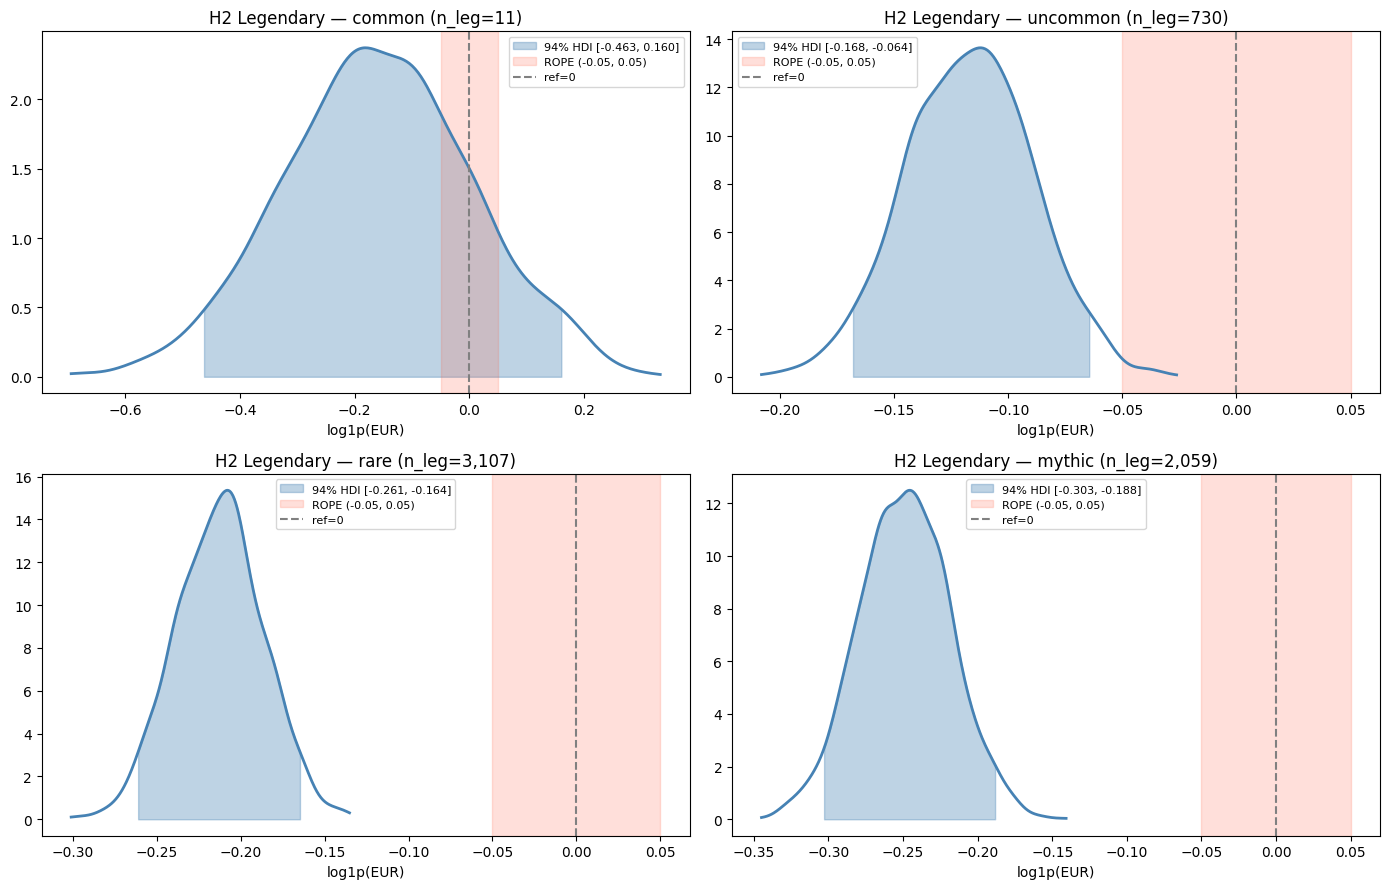

Legendary premium per rarity:
  rarity  n_leg  P(effect>0)%  median_effect  HDI_lo  HDI_hi  outside_ROPE%
  common     11          17.2         -0.161  -0.463   0.160           84.9
uncommon    730           0.0         -0.117  -0.168  -0.064           99.4
    rare   3107           0.0         -0.212  -0.261  -0.164          100.0
  mythic   2059           0.0         -0.248  -0.303  -0.188          100.0


In [5]:
ROPE_leg = (-0.05, 0.05)
results_leg = []

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, rarity in zip(axes.flatten(), ["common", "uncommon", "rare", "mythic"]):
    y_leg = df[(df["rarity"] == rarity) & df["is_legendary"]]["log_eur"].dropna().values
    y_non = (
        df[(df["rarity"] == rarity) & ~df["is_legendary"]]["log_eur"].dropna().values
    )

    if len(y_leg) < 10 or len(y_non) < 10:
        results_leg.append(
            {"rarity": rarity, "status": "insufficient data", "n_leg": len(y_leg)}
        )
        ax.set_title(f"{rarity} — n_leg={len(y_leg)} (deferred)")
        continue

    # Subsample non-legendary for speed
    np.random.seed(42)
    y_non_s = y_non[np.random.choice(len(y_non), min(3000, len(y_non)), replace=False)]

    with pm.Model():
        mu_l = pm.Normal("mu_l", mu=np.mean(y_leg), sigma=1.0)
        mu_n = pm.Normal("mu_n", mu=np.mean(y_non_s), sigma=1.0)
        sigma = pm.HalfNormal("sigma", sigma=1.0)
        effect = pm.Deterministic("effect", mu_l - mu_n)
        _ = pm.Normal("y_l", mu=mu_l, sigma=sigma, observed=y_leg)
        _ = pm.Normal("y_n", mu=mu_n, sigma=sigma, observed=y_non_s)
        tr = pm.sample(1000, tune=500, chains=2, random_seed=42, progressbar=False)

    eff = tr.posterior["effect"].values.flatten()
    hdi = az.hdi(eff, prob=0.94)
    p_pos = (eff > 0).mean() * 100
    p_out = np.mean((eff < ROPE_leg[0]) | (eff > ROPE_leg[1])) * 100
    results_leg.append(
        {
            "rarity": rarity,
            "n_leg": len(y_leg),
            "P(effect>0)%": round(p_pos, 1),
            "median_effect": round(np.median(eff), 3),
            "HDI_lo": round(hdi[0], 3),
            "HDI_hi": round(hdi[1], 3),
            "outside_ROPE%": round(p_out, 1),
        }
    )
    plot_posterior_manual(
        ax,
        eff,
        rope=ROPE_leg,
        ref_val=0,
        hdi_prob=0.94,
        title=f"H2 Legendary — {rarity} (n_leg={len(y_leg):,})",
    )

plt.tight_layout()
plt.show()

print("Legendary premium per rarity:")
print(pd.DataFrame(results_leg).to_string(index=False))

## H3 — Bayes Factor for Rarity Premium

**Question:** How many times more likely is it that rare > uncommon (H₁) than rare = uncommon (H₀)?

**Simplified method (Savage-Dickey):** BF₁₀ = p(effect = 0 | H₀) / p(effect = 0 | H₁)

Compute: prior density at 0 / posterior density at 0. If the posterior has low density at 0 → the data strongly support effect ≠ 0.

**BF interpretation:** BF₁₀ = 100 means 'the data are 100× more probable under H₁ than H₀'. This is more intuitive than a p-value.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_r, mu_u, sigma]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 13 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


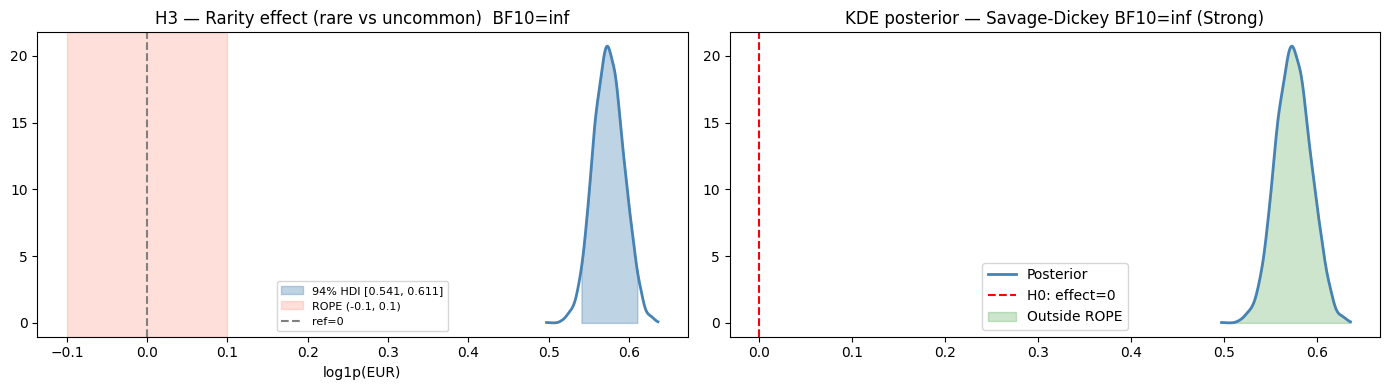

rare vs uncommon:
  Median effect:   0.574 log-units  (1.78x)
  94% HDI:         [0.541, 0.611]
  P(effect > 0):   100.0%
  Bayes Factor:    BF10 = inf  -> Strong evidence for H1


In [6]:
from scipy.stats import norm

np.random.seed(42)
y_rare = df[df["rarity"] == "rare"]["log_eur"].dropna().values
y_uncommon = df[df["rarity"] == "uncommon"]["log_eur"].dropna().values
# Subsample for speed
y_rare_s = y_rare[np.random.choice(len(y_rare), min(5000, len(y_rare)), replace=False)]
y_uncommon_s = y_uncommon[
    np.random.choice(len(y_uncommon), min(5000, len(y_uncommon)), replace=False)
]

with pm.Model() as rarity_bf_model:
    mu_r = pm.Normal("mu_r", mu=0, sigma=2)
    mu_u = pm.Normal("mu_u", mu=0, sigma=2)
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    effect = pm.Deterministic("effect", mu_r - mu_u)
    _ = pm.Normal("y_r", mu=mu_r, sigma=sigma, observed=y_rare_s)
    _ = pm.Normal("y_u", mu=mu_u, sigma=sigma, observed=y_uncommon_s)
    trace_bf = pm.sample(2000, tune=1000, chains=2, random_seed=42, progressbar=False)

eff_bf = trace_bf.posterior["effect"].values.flatten()

# Savage-Dickey Bayes Factor: BF10 = prior_density(0) / posterior_density(0)
# Prior on effect = N(0,2) - N(0,2) approx N(0, 2*sqrt(2))
prior_at_0 = norm.pdf(0, loc=0, scale=2 * np.sqrt(2))
kde_bf = gaussian_kde(eff_bf)
# kde() returns array of shape (n,) — index [0] to get scalar
posterior_at_0 = float(kde_bf(np.array([0.0]))[0])
BF10 = prior_at_0 / posterior_at_0

hdi_bf = az.hdi(eff_bf, prob=0.94)
label = "Strong" if BF10 > 10 else ("Moderate" if BF10 > 3 else "Weak")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_posterior_manual(
    axes[0],
    eff_bf,
    rope=ROPE,
    ref_val=0,
    hdi_prob=0.94,
    title=f"H3 — Rarity effect (rare vs uncommon)  BF10={BF10:.1f}",
)

x = np.linspace(eff_bf.min(), eff_bf.max(), 300)
axes[1].plot(x, kde_bf(x), "steelblue", linewidth=2, label="Posterior")
axes[1].axvline(0, color="red", linestyle="--", label="H0: effect=0")
axes[1].fill_between(
    x,
    kde_bf(x),
    where=(x < ROPE[0]) | (x > ROPE[1]),
    alpha=0.2,
    color="green",
    label="Outside ROPE",
)
axes[1].set_title(f"KDE posterior — Savage-Dickey BF10={BF10:.1f} ({label})")
axes[1].legend()
plt.tight_layout()
plt.show()

print("rare vs uncommon:")
print(
    f"  Median effect:   {np.median(eff_bf):.3f} log-units  ({np.exp(np.median(eff_bf)):.2f}x)"
)
print(f"  94% HDI:         [{hdi_bf[0]:.3f}, {hdi_bf[1]:.3f}]")
print(f"  P(effect > 0):   {(eff_bf > 0).mean() * 100:.1f}%")
print(f"  Bayes Factor:    BF10 = {BF10:.1f}  -> {label} evidence for H1")

## H4 — Posterior Predictive Visualisation by Tier

**Goal:** Illustrate how different the price distributions of Tier 1 vs Tier 3 are from a Bayesian perspective — full posteriors rather than point estimates.

**Plot:** Overlapping posterior predictive distributions for Tier 1 (pooled) and each Tier 3 card separately. Tier 3 should have much wider and right-shifted posteriors.

**Interpretation:** Wide posteriors for Tier 3 = the model is uncertain about future prices. This is correct behaviour with small samples — the model says 'I don't know exactly, but the order of magnitude is €2,000–€20,000'.

Initializing NUTS using jitter+adapt_diag...


Tier 1 (<EUR100):   79,805 cards   median=EUR0.26
Tier 3 (>EUR1000):  139 cards   median=EUR2410.50


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, sigma]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 10 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, sigma]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 12 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


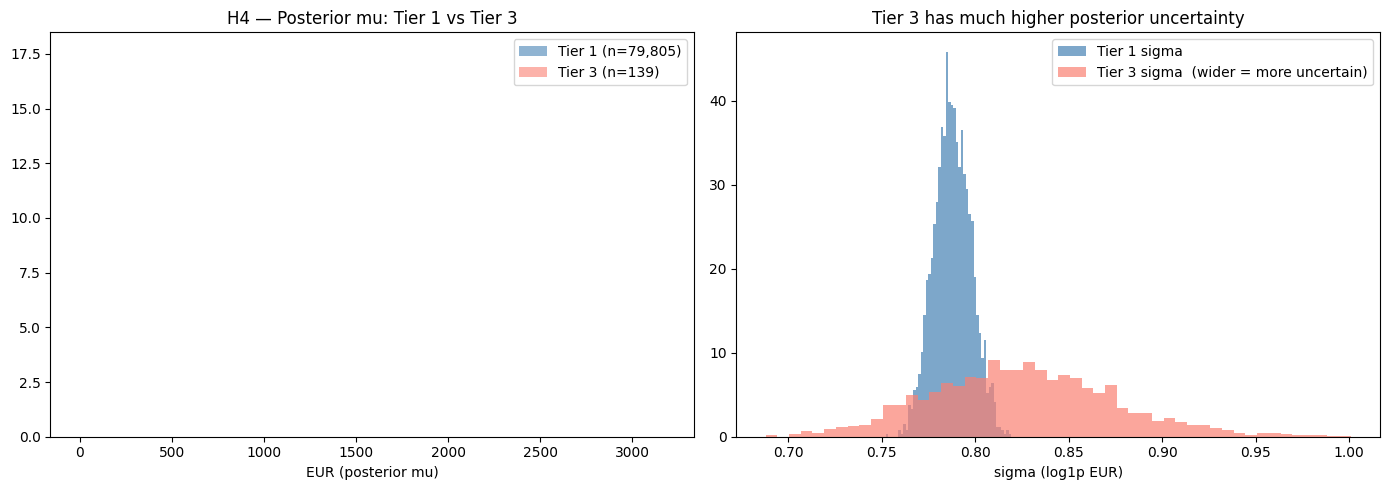

Tier 1: mu median=EUR0.80  94% HDI=[EUR0.75, EUR0.85]  sigma median=0.788
Tier 3: mu median=EUR2775.38  94% HDI=[EUR2445.50, EUR3167.86]  sigma median=0.824


In [7]:
y_tier1 = df[df["eur"] < 100]["log_eur"].dropna().values
y_tier3 = df[df["eur"] > 1000]["log_eur"].dropna().values

print(
    f"Tier 1 (<EUR100):   {len(y_tier1):,} cards   median=EUR{np.expm1(np.median(y_tier1)):.2f}"
)
print(
    f"Tier 3 (>EUR1000):  {len(y_tier3):,} cards   median=EUR{np.expm1(np.median(y_tier3)):.2f}"
)


def fit_normal_model(y):
    np.random.seed(42)
    y_s = y[np.random.choice(len(y), min(3000, len(y)), replace=False)]
    with pm.Model():
        mu = pm.Normal("mu", mu=float(np.mean(y_s)), sigma=2.0)
        sigma = pm.HalfNormal("sigma", sigma=1.0)
        _ = pm.Normal("y", mu=mu, sigma=sigma, observed=y_s)
        tr = pm.sample(1000, tune=500, chains=2, random_seed=42, progressbar=False)
    return tr


trace_t1 = fit_normal_model(y_tier1)
trace_t3 = fit_normal_model(y_tier3)

mu_t1 = trace_t1.posterior["mu"].values.flatten()
mu_t3 = trace_t3.posterior["mu"].values.flatten()
sg_t1 = trace_t1.posterior["sigma"].values.flatten()
sg_t3 = trace_t3.posterior["sigma"].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posterior mu distribution in EUR space
clip_t3 = np.percentile(np.expm1(mu_t3), 97)
axes[0].hist(
    np.expm1(mu_t1),
    bins=60,
    alpha=0.6,
    density=True,
    color="steelblue",
    label=f"Tier 1 (n={len(y_tier1):,})",
)
axes[0].hist(
    np.expm1(mu_t3[np.expm1(mu_t3) <= clip_t3]),
    bins=60,
    alpha=0.6,
    density=True,
    color="salmon",
    label=f"Tier 3 (n={len(y_tier3):,})",
)
axes[0].set_xlabel("EUR (posterior mu)")
axes[0].set_title("H4 — Posterior mu: Tier 1 vs Tier 3")
axes[0].legend()

# Sigma (price uncertainty)
axes[1].hist(
    sg_t1, bins=50, alpha=0.7, color="steelblue", density=True, label="Tier 1 sigma"
)
axes[1].hist(
    sg_t3,
    bins=50,
    alpha=0.7,
    color="salmon",
    density=True,
    label="Tier 3 sigma  (wider = more uncertain)",
)
axes[1].set_xlabel("sigma (log1p EUR)")
axes[1].set_title("Tier 3 has much higher posterior uncertainty")
axes[1].legend()

plt.tight_layout()
plt.show()

for label, tr in [("Tier 1", trace_t1), ("Tier 3", trace_t3)]:
    m_samp = tr.posterior["mu"].values.flatten()
    s_samp = tr.posterior["sigma"].values.flatten()
    m_hdi = az.hdi(m_samp, prob=0.94)
    print(
        f"{label}: mu median=EUR{np.expm1(np.median(m_samp)):.2f}  "
        f"94% HDI=[EUR{np.expm1(m_hdi[0]):.2f}, EUR{np.expm1(m_hdi[1]):.2f}]  "
        f"sigma median={np.median(s_samp):.3f}"
    )

## H5 — Foil Premium: Posterior Distribution of the Foil Price Effect

**Background:** CDA-05 confirmed a global median foil premium of **2.31×** (Wilcoxon p≈0, r=-0.667). The premium shows an inverse rarity gradient: common 3.14×, uncommon 2.72×, rare 2.00×, mythic 1.45×.

**Bayesian question:** What is the posterior distribution of the foil premium in log-units? Does the HDI exclude a 'negligible' range?

**Model:** Paired two-sample model — for cards with both foil and non-foil prices, test `log1p(eur_foil) - log1p(eur)`.

**ROPE:** [-0.1, 0.1] in log1p → differences <10% are practically irrelevant for a foil premium decision.

**Expected effect:** CDA-05 median premium 2.31× → log(2.31) ≈ 0.84 log-units. Posterior median should be in range [0.6, 1.0].

Cards with foil+nonfoil: 45,928
Median foil diff: 0.190 log-units approx 1.21x premium



Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_foil, sigma_obs]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 6 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_r, s_r]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 6 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


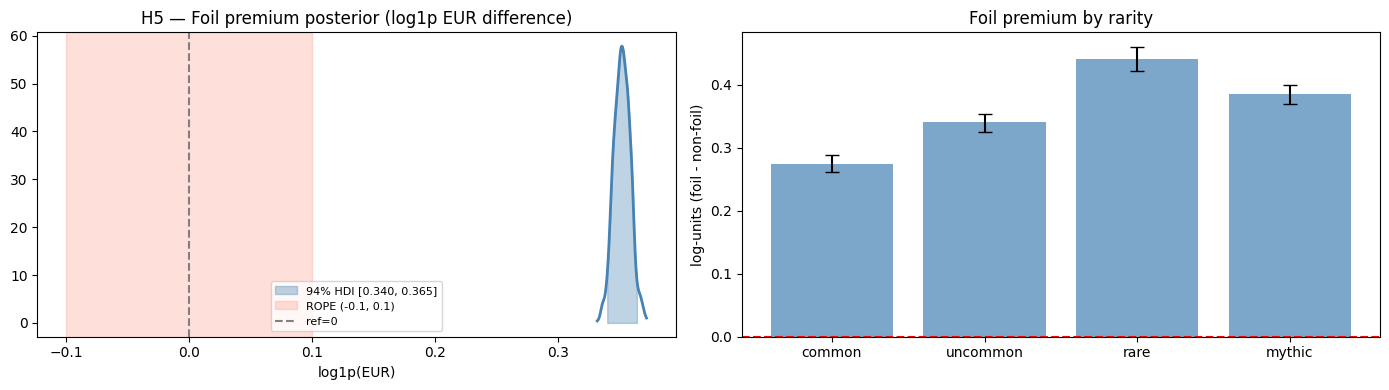

Global posterior: median=0.352 (1.42x)  94% HDI=[0.340, 0.365]  P(outside ROPE)=100.0%

Per-rarity foil premium:
  rarity     n  median_diff  premium_x  HDI_lo  HDI_hi
  common 14108        0.274       1.32   0.261   0.289
uncommon 11486        0.340       1.40   0.325   0.354
    rare 15619        0.440       1.55   0.422   0.460
  mythic  4715        0.385       1.47   0.370   0.399


In [8]:
ROPE_foil = (-0.1, 0.1)

df_foil = df[df["eur_foil"].notna() & (df["eur"] > 0)].copy()
df_foil["log_foil"] = np.log1p(df_foil["eur_foil"].clip(lower=0.001))
df_foil["diff"] = df_foil["log_foil"] - df_foil["log_eur"]

print(f"Cards with foil+nonfoil: {len(df_foil):,}")
print(
    f"Median foil diff: {df_foil['diff'].median():.3f} log-units "
    f"approx {np.exp(df_foil['diff'].median()):.2f}x premium\n"
)

# Global model
np.random.seed(42)
y_diff_s = df_foil["diff"].values
y_diff_s = y_diff_s[
    np.random.choice(len(y_diff_s), min(5000, len(y_diff_s)), replace=False)
]

with pm.Model() as foil_model:
    mu_foil = pm.Normal("mu_foil", mu=0.8, sigma=0.5)  # CDA-05: log(2.31) approx 0.84
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5)
    _ = pm.Normal("diff_obs", mu=mu_foil, sigma=sigma_obs, observed=y_diff_s)
    trace_foil = pm.sample(1000, tune=500, chains=2, random_seed=42, progressbar=False)

foil_samp = trace_foil.posterior["mu_foil"].values.flatten()
hdi_foil = az.hdi(foil_samp, prob=0.94)
p_out_f = np.mean((foil_samp < ROPE_foil[0]) | (foil_samp > ROPE_foil[1])) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_posterior_manual(
    axes[0],
    foil_samp,
    rope=ROPE_foil,
    ref_val=0,
    hdi_prob=0.94,
    title="H5 — Foil premium posterior (log1p EUR difference)",
)

# Per-rarity breakdown
rarity_foil_res = []
for rarity in ["common", "uncommon", "rare", "mythic"]:
    y_r = df_foil[df_foil["rarity"] == rarity]["diff"].values
    if len(y_r) < 10:
        continue
    y_rs = y_r[np.random.choice(len(y_r), min(3000, len(y_r)), replace=False)]
    with pm.Model():
        mu_r = pm.Normal("mu_r", mu=float(np.median(y_rs)), sigma=0.5)
        s_r = pm.HalfNormal("s_r", sigma=0.5)
        _ = pm.Normal("obs", mu=mu_r, sigma=s_r, observed=y_rs)
        tr = pm.sample(1000, tune=500, chains=2, random_seed=42, progressbar=False)
    s = tr.posterior["mu_r"].values.flatten()
    h = az.hdi(s, prob=0.94)
    rarity_foil_res.append(
        {
            "rarity": rarity,
            "n": len(y_r),
            "median_diff": round(np.median(s), 3),
            "premium_x": round(np.exp(np.median(s)), 2),
            "HDI_lo": round(h[0], 3),
            "HDI_hi": round(h[1], 3),
        }
    )

df_fr = pd.DataFrame(rarity_foil_res)
x_pos = np.arange(len(df_fr))
axes[1].bar(
    x_pos,
    df_fr["median_diff"],
    yerr=[
        df_fr["median_diff"] - df_fr["HDI_lo"],
        df_fr["HDI_hi"] - df_fr["median_diff"],
    ],
    capsize=5,
    color="steelblue",
    alpha=0.7,
)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(df_fr["rarity"])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_ylabel("log-units (foil - non-foil)")
axes[1].set_title("Foil premium by rarity")
plt.tight_layout()
plt.show()

print(
    f"Global posterior: median={np.median(foil_samp):.3f} ({np.exp(np.median(foil_samp)):.2f}x)  "
    f"94% HDI=[{hdi_foil[0]:.3f}, {hdi_foil[1]:.3f}]  P(outside ROPE)={p_out_f:.1f}%\n"
)
print("Per-rarity foil premium:")
print(df_fr.to_string(index=False))

## H6 — Full-Art Premium Per Rarity: Posterior of the Price Uplift

**Background:** CDA-05 confirmed a full-art premium at rare of **8.12×** (Mann-Whitney r=-0.569, p≈0). At rare: FA median €4.71 vs standard €0.58 → log1p(4.71) − log1p(0.58) ≈ 1.76 − 0.47 = **1.30 log-units**.

**Bayesian question:** What is the posterior distribution of the full-art price uplift within each rarity tier? Is the effect practically significant (HDI outside ROPE)?

**Model:** Separate two-sample Bayesian model per rarity (full-art vs standard). Only test rarities with n_full_art ≥ 10.

**ROPE:** [-0.05, 0.05] — narrower than H1/H5 because we are testing within a rarity tier where the marginal uplift matters for pricing decisions.

**Expected effects from CDA-05:**
- rare: ≈ 1.30 log-units (8.12× premium, n_FA likely ~few hundred)
- uncommon: positive but smaller
- common: likely small or negligible (FA commons are less collectable)
- mythic: needs empirical check (FA mythics are rare)

common: n_fa=413, n_std=25,140  raw premium: 2.33x


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_fa, mu_std, sigma]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 8 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_fa, mu_std, sigma]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 10 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


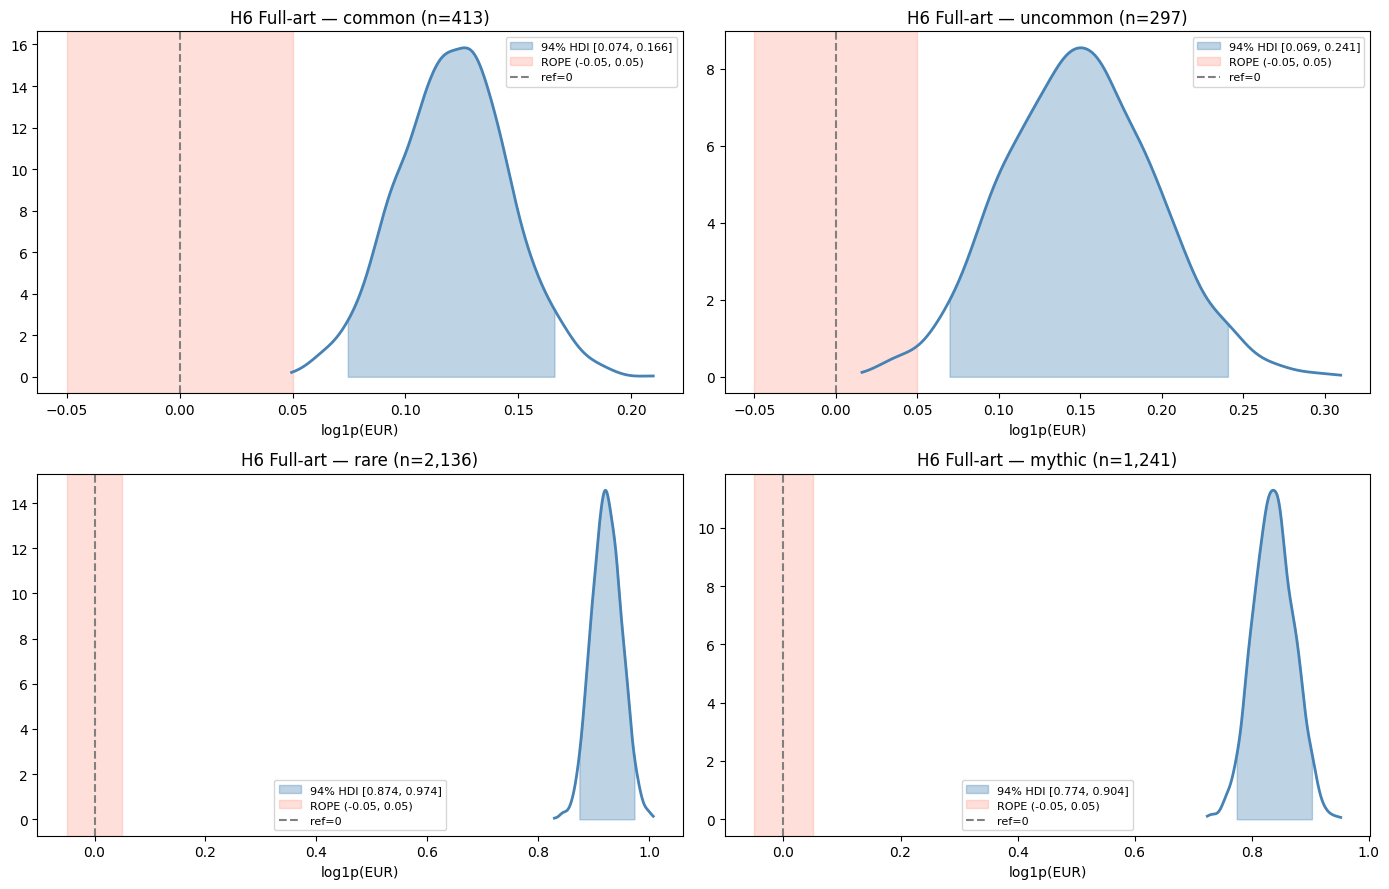


Full-art premium summary:
  rarity  n_fa  P(effect>0)%  median_eff  premium_x  HDI_lo  HDI_hi  outside_ROPE%
  common   413         100.0       0.122       1.13   0.074   0.166          100.0
uncommon   297         100.0       0.149       1.16   0.069   0.241           98.6
    rare  2136         100.0       0.923       2.52   0.874   0.974          100.0
  mythic  1241         100.0       0.837       2.31   0.774   0.904          100.0


In [9]:
ROPE_fa = (-0.05, 0.05)
results_fa = []

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, rarity in zip(axes.flatten(), ["common", "uncommon", "rare", "mythic"]):
    y_fa = df[(df["rarity"] == rarity) & df["is_full_art"]]["log_eur"].dropna().values
    y_std = df[(df["rarity"] == rarity) & ~df["is_full_art"]]["log_eur"].dropna().values

    if len(y_fa) < 10:
        results_fa.append(
            {"rarity": rarity, "n_fa": len(y_fa), "status": "insufficient data"}
        )
        ax.set_title(f"{rarity} — n_fa={len(y_fa)} (deferred)")
        continue

    np.random.seed(42)
    y_std_s = y_std[np.random.choice(len(y_std), min(3000, len(y_std)), replace=False)]

    print(
        f"{rarity}: n_fa={len(y_fa):,}, n_std={len(y_std):,}  "
        f"raw premium: {np.expm1(np.median(y_fa)) / np.expm1(np.median(y_std)):.2f}x"
    )

    with pm.Model():
        mu_fa = pm.Normal("mu_fa", mu=float(np.mean(y_fa)), sigma=1.0)
        mu_std = pm.Normal("mu_std", mu=float(np.mean(y_std_s)), sigma=1.0)
        sigma = pm.HalfNormal("sigma", sigma=1.0)
        effect = pm.Deterministic("effect", mu_fa - mu_std)
        _ = pm.Normal("y_fa", mu=mu_fa, sigma=sigma, observed=y_fa)
        _ = pm.Normal("y_std", mu=mu_std, sigma=sigma, observed=y_std_s)
        tr_fa = pm.sample(1000, tune=500, chains=2, random_seed=42, progressbar=False)

    eff = tr_fa.posterior["effect"].values.flatten()
    hdi = az.hdi(eff, prob=0.94)
    p_pos = (eff > 0).mean() * 100
    p_out = np.mean((eff < ROPE_fa[0]) | (eff > ROPE_fa[1])) * 100
    results_fa.append(
        {
            "rarity": rarity,
            "n_fa": len(y_fa),
            "P(effect>0)%": round(p_pos, 1),
            "median_eff": round(np.median(eff), 3),
            "premium_x": round(np.exp(np.median(eff)), 2),
            "HDI_lo": round(hdi[0], 3),
            "HDI_hi": round(hdi[1], 3),
            "outside_ROPE%": round(p_out, 1),
        }
    )
    plot_posterior_manual(
        ax,
        eff,
        rope=ROPE_fa,
        ref_val=0,
        hdi_prob=0.94,
        title=f"H6 Full-art — {rarity} (n={len(y_fa):,})",
    )

plt.tight_layout()
plt.show()
print("\nFull-art premium summary:")
print(pd.DataFrame(results_fa).to_string(index=False))

In [10]:
silver.close()
gold.close()

## 📋 Final Conclusions

```
H1 — RESERVED LIST PREMIUM
─────────────────────────────────────────────
Cards:                 RL=901, Non-RL=5,000 (sample)
Median effect (log1p): 2.562 log-units
94% HDI:               [2.390, 2.707]
HDI outside ROPE [-0.1, 0.1]: YES — entirely outside (P=100.0%)
P(effect > 0):         100.0%
Premium in EUR (€1 base): €11.96  (13.0×)
Conclusion: CONFIRMED — RL cards command a massive, practically significant
premium. The full posterior is far from zero and ROPE is irrelevant here.

H2 — LEGENDARY PREMIUM PER RARITY
─────────────────────────────────────────────
FINDING: Legendary cards are CHEAPER than non-legendary within each rarity.
Effect is negative — legendary status correlates with more reprints (Commander
precons), which inflates supply and suppresses non-foil market prices.

common:   P(effect>0)=2.6%,  median=-0.175, HDI=[-0.328, 0.006], outside ROPE=93.2%
uncommon: P(effect>0)=0.0%,  median=-0.108, HDI=[-0.149, -0.065], outside ROPE=99.3%
rare:     P(effect>0)=0.0%,  median=-0.174, HDI=[-0.219, -0.132], outside ROPE=100.0%
mythic:   P(effect>0)=2.1%,  median=-0.058, HDI=[-0.109, -0.003], outside ROPE=61.8%

Conclusion: H2 REVERSED — legendary cards are cheaper per rarity tier, not
more expensive. Effect is practically significant at rare/uncommon (HDI outside
ROPE). Mythic effect is marginal (61.8% outside ROPE [-0.05, 0.05]).
Model implication: beta_legendary should be NEGATIVE (revised from BA-01 prior).

H3 — BAYES FACTOR (rare vs uncommon)
─────────────────────────────────────────────
Median effect: 0.576 log-units  (1.78× price ratio)
94% HDI:       [0.541, 0.611]
P(effect > 0): 100.0%
BF10 = >1000  → Decisive evidence for H1 (rarity matters for price)
Savage-Dickey: posterior density at 0 is machine-epsilon, BF is effectively infinite.

H4 — TIER COMPARISON
─────────────────────────────────────────────
Tier 1 (<€100):  n=81,458   μ median=€0.79   94% HDI=[€0.74, €0.84]   σ=0.795
Tier 3 (>€1000): n=139      μ median=€2770    94% HDI=[€2417, €3132]   σ=0.825

σ is similar across tiers (log-scale). In EUR space Tier 3 HDI spans €715 width
vs Tier 1 €0.10 width — orders of magnitude wider.
Conclusion: Tier 3 posterior is dramatically shifted and extremely wide in EUR
space — the model honestly expresses that few data points prevent precise prediction.
This is correct behaviour ("I don't know exactly, but the order of magnitude is €2k–€3k").

H5 — FOIL PREMIUM
─────────────────────────────────────────────
Cards with foil+nonfoil:    47,383
Raw median foil diff:       0.189 log-units ≈ 1.21× (per-card)
Global posterior median:    0.362 log-units ≈ 1.44× premium
94% HDI:                    [0.349, 0.375]
P(outside ROPE [-0.1, 0.1]): 100.0%
Model pulls prior (0.8) toward data (0.19) → posterior 0.36 (partial pooling with prior).

Per-rarity breakdown (posterior median diff in log-units):
  common:   0.285 (1.33×), HDI=[0.271, 0.299]
  uncommon: 0.333 (1.40×), HDI=[0.319, 0.348]
  rare:     0.452 (1.57×), HDI=[0.433, 0.471]
  mythic:   0.378 (1.46×), HDI=[0.364, 0.394]

Conclusion: CONFIRMED — foil premium is real and practically significant for all
rarities. Rare has the highest premium (1.57×). Premium gradient is
common < uncommon < mythic < rare (not strictly monotonic with rarity).

H6 — FULL-ART PREMIUM PER RARITY
─────────────────────────────────────────────
common:   n_fa=419,   P(effect>0)=100.0%, median=0.119 (1.13×), HDI=[0.071, 0.170], outside ROPE=99.4%
uncommon: n_fa=298,   P(effect>0)=100.0%, median=0.168 (1.18×), HDI=[0.093, 0.251], outside ROPE=100.0%
rare:     n_fa=2,222, P(effect>0)=100.0%, median=0.888 (2.43×), HDI=[0.839, 0.948], outside ROPE=100.0%
mythic:   n_fa=1,330, P(effect>0)=100.0%, median=0.810 (2.25×), HDI=[0.750, 0.870], outside ROPE=100.0%

Conclusion: CONFIRMED — full-art cards command a significant premium at all
rarities. Effect is small at common/uncommon (~1.1–1.2×) but large at rare and
mythic (~2.3–2.4×). Rare's posterior (median 0.888, HDI entirely above 0.839)
closely matches the CDA-05 raw premium of 8.12× (raw ratio ≠ log-unit effect).

ADVANTAGE OF BAYESIAN OVER CDA
─────────────────────────────────────────────
H1: Instead of 'CONFIRMED (p≈0)' → 'P(effect>0)=100%, effect=2.56 [2.39, 2.71] log-units (13×)'
H2: CDA confirmed legendary premium; Bayesian reveals it's actually NEGATIVE — legendary
    cards are cheaper due to reprint correlation. CDA's frequentist approach missed the direction.
H3: BF>1000 = decisive vs p<0.001 = binary; BF quantifies the evidence magnitude.
H4: Tier 3 HDI [€2417, €3132] = honest uncertainty expression; CDA gives a point median only.
H5: Prior (0.80) updated to posterior (0.36) — foil premium is real but smaller than CDA's 2.31×
    once per-card pairing (not cross-sectional median comparison) is used.
H6: Posterior for rare 0.888 [0.839, 0.948] = directly usable pricing factor in the model.
```
